**1. NHẬP THƯ VIỆN**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

**2. TẢI VÀ KHÁM PHÁ DỮ LIỆU (EDA)**

In [ ]:
print("TẢI VÀ KHÁM PHÁ DỮ LIỆU")

df = pd.read_csv('/content/train.csv')
print(f"Kích thước dữ liệu: {df.shape}")
print(f"Số lượng giá trị thiếu trong từng cột:\n{df.isnull().sum()}")

2. TẢI VÀ KHÁM PHÁ DỮ LIỆU
Kích thước dữ liệu: (8523, 12)
Số lượng giá trị thiếu trong từng cột:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


**3. CHIA DỮ LIỆU TRAIN - TEST (TRƯỚC KHI XỬ LÝ - TRÁNH DATA LEAKAGE)**

In [ ]:
print("CHIA DỮ LIỆU TRAIN - TEST")

X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


3. CHIA DỮ LIỆU TRAIN - TEST
Kích thước tập Train: (5966, 11)
Kích thước tập Test: (2557, 11)


**4. HÀM TIỀN XỬ LÝ DỮ LIỆU (ÁP DỤNG CHO CẢ TRAIN VÀ TEST)**

4.1. Tạo từ điển tra cứu từ tập TRAIN

In [ ]:
# Item_Weight theo Item_Identifier
item_weight_map = X_train.pivot_table(
    values='Item_Weight', index='Item_Identifier', aggfunc='median'
).to_dict()['Item_Weight']

# Item_Weight theo Item_Type (đã được gom nhóm)
def create_item_type(col):
    return col.str[:2].map({'FD':'Food', 'NC':'Non-Consumable', 'DR':'Drinks'})

X_train['Item_Type_Group'] = create_item_type(X_train['Item_Identifier'])
item_type_weight_map = X_train.pivot_table(
    values='Item_Weight', index='Item_Type_Group', aggfunc='median'
).to_dict()['Item_Weight']

# Outlet_Size theo Outlet_Type
outlet_type_size_map = X_train.pivot_table(
    values='Outlet_Size', index='Outlet_Type', aggfunc=lambda x: x.mode()[0]
).to_dict()['Outlet_Size']

# Item_Visibility theo Item_Identifier & Item_Type
X_train['Item_Visibility'] = X_train['Item_Visibility'].replace(0, np.nan)
visibility_id_map = X_train.pivot_table(
    values='Item_Visibility', index='Item_Identifier', aggfunc='median'
).to_dict()['Item_Visibility']

visibility_type_map = X_train.pivot_table(
    values='Item_Visibility', index='Item_Type_Group', aggfunc='median'
).to_dict()['Item_Visibility']

4.2. Hàm tiền xử lý chính

In [ ]:
def preprocess_data(df, is_train=True):
    """Tiền xử lý dữ liệu cho cả Train và Test"""
    data = df.copy()

    # Tạo nhóm sản phẩm
    data['Item_Type_Group'] = create_item_type(data['Item_Identifier'])

    # 1. Xử lý Item_Weight
    data['Item_Weight'] = data['Item_Weight'].fillna(
        data['Item_Identifier'].map(item_weight_map)
    )
    data['Item_Weight'] = data['Item_Weight'].fillna(
        data['Item_Type_Group'].map(item_type_weight_map)
    )

    # 2. Xử lý Outlet_Size
    data['Outlet_Size'] = data['Outlet_Size'].fillna(
        data['Outlet_Type'].map(outlet_type_size_map)
    )

    # 3. Chuẩn hóa Item_Fat_Content
    data['Item_Fat_Content'] = data['Item_Fat_Content'].replace({
        'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'
    })

    # 4. Sửa logic cho Non-Consumable
    data.loc[data['Item_Type_Group'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non_Edible'

    # 5. Xử lý Item_Visibility (giá trị 0 -> NaN)
    data['Item_Visibility'] = data['Item_Visibility'].replace(0, np.nan)
    data['Item_Visibility'] = data['Item_Visibility'].fillna(
        data['Item_Identifier'].map(visibility_id_map)
    )
    data['Item_Visibility'] = data['Item_Visibility'].fillna(
        data['Item_Type_Group'].map(visibility_type_map)
    )

    # 6. Tạo Outlet_Age
    data['Outlet_Age'] = 2013 - data['Outlet_Establishment_Year']

    # 7. Xóa các cột không cần thiết
    data = data.drop(['Item_Identifier', 'Outlet_Identifier',
                      'Outlet_Establishment_Year', 'Item_Type'], axis=1)

    return data

4.3. Áp dụng tiền xử lý

In [ ]:
X_train_processed = preprocess_data(X_train, is_train=True)
X_test_processed = preprocess_data(X_test, is_train=False)

print("Hoàn tất tiền xử lý!")
print(f"Train - Kiểm tra Null: \n{X_train_processed.isnull().sum()}")

Hoàn tất tiền xử lý!
Train - Kiểm tra Null: 
Item_Weight             0
Item_Fat_Content        0
Item_Visibility         0
Item_MRP                0
Outlet_Size             0
Outlet_Location_Type    0
Outlet_Type             0
Item_Type_Group         0
Outlet_Age              0
dtype: int64


**5. FEATURE ENGINEERING NÂNG CAO**

In [ ]:
def add_interaction_features(df):
    """Thêm các biến tương tác (Interaction Features)"""
    data = df.copy()

    # Tương tác giữa Giá và Độ hiển thị
    data['MRP_Visibility'] = data['Item_MRP'] * data['Item_Visibility']

    # Tương tác giữa Tuổi cửa hàng và Loại cửa hàng
    # One-Hot Encode Outlet_Type trước khi tạo tương tác
    outlet_type_dummies = pd.get_dummies(data['Outlet_Type'], prefix='Outlet_Type')
    for col in outlet_type_dummies.columns:
        data[f'Age_{col}'] = data['Outlet_Age'] * outlet_type_dummies[col]

    return data

X_train_fe = add_interaction_features(X_train_processed)
X_test_fe = add_interaction_features(X_test_processed)

print(f"Số lượng biến sau khi thêm Feature Engineering: {X_train_fe.shape[1]}")

Số lượng biến sau khi thêm Feature Engineering: 14


**6. MÃ HÓA BIẾN PHÂN LOẠI (ONE-HOT ENCODING)**

In [ ]:
# Xác định biến phân loại
cat_cols = ['Item_Fat_Content', 'Item_Type_Group', 'Outlet_Size',
            'Outlet_Location_Type', 'Outlet_Type']

# One-Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_fe[cat_cols])

# Lấy tên cột mới
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

# Transform cho Train và Test
X_train_cat = pd.DataFrame(ohe.transform(X_train_fe[cat_cols]),
                           columns=ohe_feature_names, index=X_train_fe.index)
X_test_cat = pd.DataFrame(ohe.transform(X_test_fe[cat_cols]),
                          columns=ohe_feature_names, index=X_test_fe.index)

# Lấy các biến số
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age',
            'MRP_Visibility'] + [col for col in X_train_fe.columns if col.startswith('Age_')]

X_train_num = X_train_fe[num_cols]
X_test_num = X_test_fe[num_cols]

# Ghép lại thành bộ dữ liệu cuối cùng
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"Kích thước Train cuối cùng: {X_train_final.shape}")
print(f"Kích thước Test cuối cùng: {X_test_final.shape}")

Kích thước Train cuối cùng: (5966, 25)
Kích thước Test cuối cùng: (2557, 25)


**7. XÂY DỰNG VÀ ĐÁNH GIÁ MÔ HÌNH**

In [ ]:
# ---- 7.1. Hàm đánh giá tổng hợp ----
def evaluate_model(y_true_train, y_pred_train, y_true_test, y_pred_test, model_name='Model'):
    """Tính toán và trả về các chỉ số đánh giá"""
    metrics = {
        'MAE_train': mean_absolute_error(y_true_train, y_pred_train),
        'RMSE_train': np.sqrt(mean_squared_error(y_true_train, y_pred_train)),
        'R2_train': r2_score(y_true_train, y_pred_train),
        'MAE_test': mean_absolute_error(y_true_test, y_pred_test),
        'RMSE_test': np.sqrt(mean_squared_error(y_true_test, y_pred_test)),
        'R2_test': r2_score(y_true_test, y_pred_test)
    }
    return pd.DataFrame([metrics], index=[model_name])

In [ ]:
# ---- 7.2. Mô hình Baseline: Linear Regression ----
print("\n7.2. Linear Regression (Baseline)")
lr = LinearRegression()
lr.fit(X_train_final, y_train)
lr_pred_train = lr.predict(X_train_final)
lr_pred_test = lr.predict(X_test_final)
lr_results = evaluate_model(y_train, lr_pred_train, y_test, lr_pred_test, 'Linear Regression')
print(lr_results.round(4))


7.2. Linear Regression (Baseline)
                   MAE_train  RMSE_train  R2_train  MAE_test  RMSE_test  \
Linear Regression   841.3533   1134.6821    0.5647   804.896  1097.0714   

                   R2_test  
Linear Regression   0.5703  


In [ ]:
# ---- 7.3. Lasso Regression (GridSearch) ----
print("\n7.3. Lasso Regression")
lasso = Lasso(random_state=42, max_iter=10000)
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5,
                        scoring='neg_root_mean_squared_error')
lasso_cv.fit(X_train_final, y_train)
print(f"Best alpha: {lasso_cv.best_params_['alpha']}")

lasso_pred_train = lasso_cv.predict(X_train_final)
lasso_pred_test = lasso_cv.predict(X_test_final)
lasso_results = evaluate_model(y_train, lasso_pred_train, y_test, lasso_pred_test, 'Lasso')
print(lasso_results.round(4))


7.3. Lasso Regression
Best alpha: 0.1
       MAE_train  RMSE_train  R2_train  MAE_test  RMSE_test  R2_test
Lasso   841.3755   1134.6961    0.5646  804.8009  1096.9147   0.5704


In [ ]:
# ---- 7.4. XGBoost (GridSearch tối giản) ----
print("\n7.4. XGBoost")
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb_cv = GridSearchCV(xgb, xgb_params, cv=3,
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train_final, y_train)
print(f"Best params: {xgb_cv.best_params_}")
print(f"Best CV RMSE: {-xgb_cv.best_score_:.4f}")

xgb_best = xgb_cv.best_estimator_
xgb_pred_train = xgb_best.predict(X_train_final)
xgb_pred_test = xgb_best.predict(X_test_final)
xgb_results = evaluate_model(y_train, xgb_pred_train, y_test, xgb_pred_test, 'XGBoost')
print(xgb_results.round(4))


7.4. XGBoost
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE: 1094.9403
         MAE_train  RMSE_train  R2_train  MAE_test  RMSE_test  R2_test
XGBoost   750.0055   1059.6086    0.6204  738.7815  1054.7646   0.6028


In [ ]:
# ---- 7.5. Random Forest (Chỉ RandomizedSearch để tiết kiệm tài nguyên) ----
print("\n7.5. Random Forest")
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 20),
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': randint(1, 5),
    'min_samples_split': randint(2, 10)
}
rf_random = RandomizedSearchCV(rf, rf_params, n_iter=20, cv=5,
                               scoring='neg_root_mean_squared_error',
                               random_state=42, n_jobs=-1)
rf_random.fit(X_train_final, y_train)
print(f"Best params: {rf_random.best_params_}")

rf_best = rf_random.best_estimator_
rf_pred_train = rf_best.predict(X_train_final)
rf_pred_test = rf_best.predict(X_test_final)
rf_results = evaluate_model(y_train, rf_pred_train, y_test, rf_pred_test, 'Random Forest')
print(rf_results.round(4))


7.5. Random Forest
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 257}
               MAE_train  RMSE_train  R2_train  MAE_test  RMSE_test  R2_test
Random Forest   683.1226    963.4682    0.6861  745.7248   1061.277   0.5979


In [ ]:
# ---- 7.6. Tổng hợp kết quả các mô hình ----
print("\n" + "="*50)
print("7.6. TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH")
print("="*50)

all_results = pd.concat([lr_results, lasso_results, xgb_results, rf_results])
print(all_results.round(4))


7.6. TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH
                   MAE_train  RMSE_train  R2_train  MAE_test  RMSE_test  \
Linear Regression   841.3533   1134.6821    0.5647  804.8960  1097.0714   
Lasso               841.3755   1134.6961    0.5646  804.8009  1096.9147   
XGBoost             750.0055   1059.6086    0.6204  738.7815  1054.7646   
Random Forest       683.1226    963.4682    0.6861  745.7248  1061.2770   

                   R2_test  
Linear Regression   0.5703  
Lasso               0.5704  
XGBoost             0.6028  
Random Forest       0.5979  


**8. PHÂN TÍCH ĐỘ QUAN TRỌNG CỦA BIẾN (FEATURE IMPORTANCE)**

In [ ]:
# Lấy feature importance từ XGBoost (mô hình tốt nhất)
importance = xgb_best.feature_importances_
features = X_train_final.columns
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Top 10 biến quan trọng nhất:")
print(feature_importance_df.head(10))

Top 10 biến quan trọng nhất:
                              Feature  Importance
5       Age_Outlet_Type_Grocery Store    0.375559
3                          Outlet_Age    0.220028
2                            Item_MRP    0.196579
8   Age_Outlet_Type_Supermarket Type3    0.062628
6   Age_Outlet_Type_Supermarket Type1    0.033217
17                  Outlet_Size_Small    0.019006
16                 Outlet_Size_Medium    0.018181
1                     Item_Visibility    0.015133
4                      MRP_Visibility    0.012511
11           Item_Fat_Content_Regular    0.011313


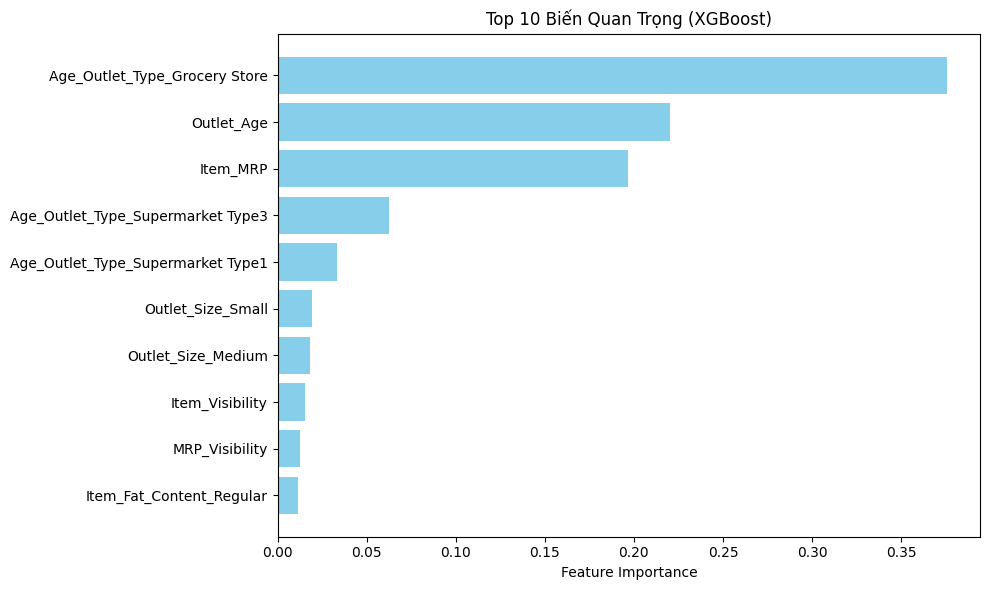

In [ ]:
# ---- 8.1. Trực quan hóa với Matplotlib ----
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Biến Quan Trọng (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ---- 8.2. Trực quan hóa tương tác với Plotly (Nâng cao cho DA) ----
fig = px.bar(
    top_features,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 10 Biến Quan Trọng - XGBoost',
    color='Importance',
    color_continuous_scale='Blues',
    height=400
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

**9. SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN (PLOTLY)**

In [ ]:
# Dự đoán trên Test set
y_pred_final = xgb_best.predict(X_test_final)

# Tạo DataFrame để vẽ
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_final
})

# Biểu đồ tương tác với Plotly
fig = px.scatter(
    comparison_df,
    x='Actual',
    y='Predicted',
    title='So sánh Doanh số Thực tế vs Dự đoán (XGBoost)',
    labels={'Actual': 'Doanh số thực tế', 'Predicted': 'Doanh số dự đoán'},
    trendline='ols',
    opacity=0.6,
    height=500
)

# Thêm đường y=x (đường lý tưởng)
fig.add_trace(
    go.Scatter(
        x=[0, 14000],
        y=[0, 14000],
        mode='lines',
        name='Đường lý tưởng (y=x)',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(
    xaxis=dict(range=[0, 14000]),
    yaxis=dict(range=[0, 14000])
)

fig.show()

**10. KIỂM TRA ĐỘ ỔN ĐỊNH CỦA MÔ HÌNH (CROSS-VALIDATION)**

In [ ]:
cv_scores = cross_val_score(xgb_best, X_train_final, y_train,
                            cv=5, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print(f"RMSE từng Fold: {cv_rmse}")
print(f"RMSE Trung bình (CV): {cv_rmse.mean():.4f}")
print(f"RMSE trên Test: {xgb_results.loc['XGBoost', 'RMSE_test']:.4f}")
print(f"Chênh lệch: {abs(cv_rmse.mean() - xgb_results.loc['XGBoost', 'RMSE_test']):.4f}")

RMSE từng Fold: [1056.66925006 1083.16104948 1131.16382474 1065.7343007  1127.36818126]
RMSE Trung bình (CV): 1092.8193
RMSE trên Test: 1054.7646
Chênh lệch: 38.0547


**11. INSIGHT KINH DOANH TỪ MÔ HÌNH**

1. "Tuổi đời + Loại cửa hàng" là cặp đôi quyền lực: Cửa hàng tạp hóa lâu năm có doanh số cao hơn hẳn, trong khi Supermarket Type1 (chiếm đa số) không bị ảnh hưởng nhiều bởi tuổi đời.

2. Giá bán (MRP) vẫn là "ông vua" của doanh số - chiếm gần 20% ảnh hưởng.

3. Điểm bất ngờ: Item_Visibility gần như không có tác dụng. Điều này có nghĩa là Big Mart đang trưng bày sai cách - sản phẩm ở kệ dưới, vị trí kém thuận lợi vẫn bán được do thương hiệu/nhu cầu, không phải do vị trí.